In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

import shap
import joblib
import json

In [2]:
X_test = pd.read_csv("../data/final/X_test.csv")

y_test = pd.read_csv("../data/final/y_test.csv").squeeze()

model = joblib.load("../models/fire_model.pkl")

In [3]:
y_probs = model.predict_proba(X_test)[:,1]

y_preds = model.predict(X_test)

In [4]:
print("ROC AUC:", roc_auc_score(y_test, y_probs))

print("Balanced Accuracy:",
      balanced_accuracy_score(y_test, y_preds))

print("MCC:",
      matthews_corrcoef(y_test, y_preds))

ROC AUC: 0.6811111111111111
Balanced Accuracy: 0.6248148148148148
MCC: 0.24949106196442594


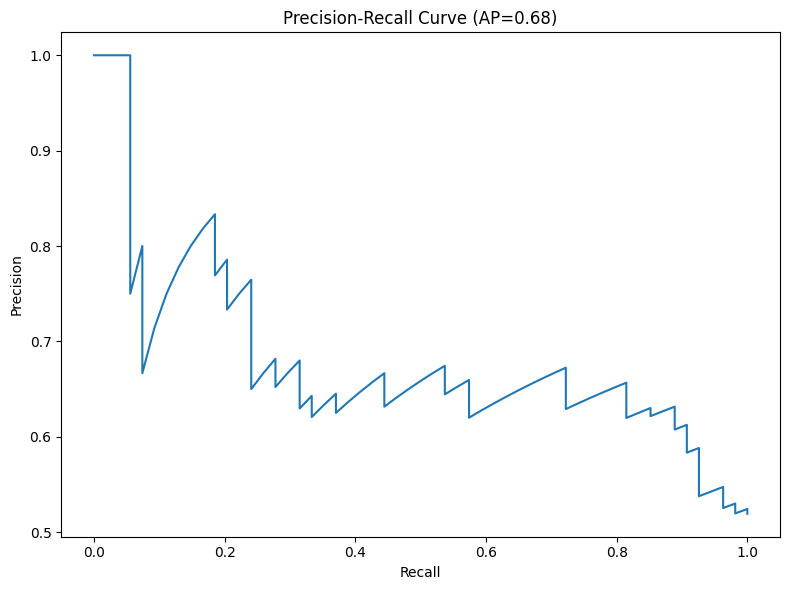

In [5]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_probs
)

ap_score = average_precision_score(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(recall, precision)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title(f"Precision-Recall Curve (AP={ap_score:.2f})")

plt.tight_layout()

plt.savefig("../reports/pr_curve.png")

plt.show()

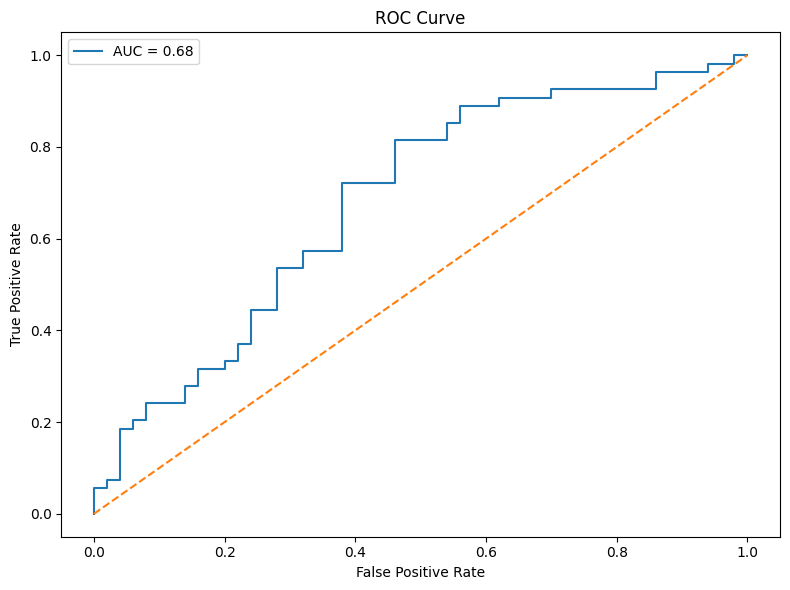

In [6]:
fpr, tpr, _ = roc_curve(y_test, y_probs)

auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig("../reports/roc_curve_advanced.png")

plt.show()

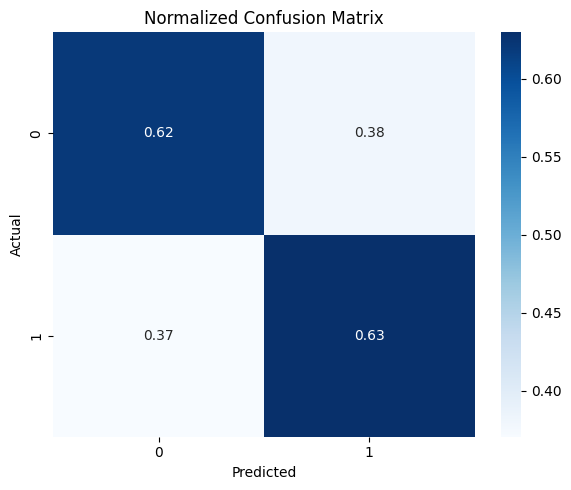

In [7]:
cm = confusion_matrix(y_test, y_preds)

cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_normalized,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Normalized Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../reports/confusion_matrix_normalized.png")

plt.show()

In [8]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

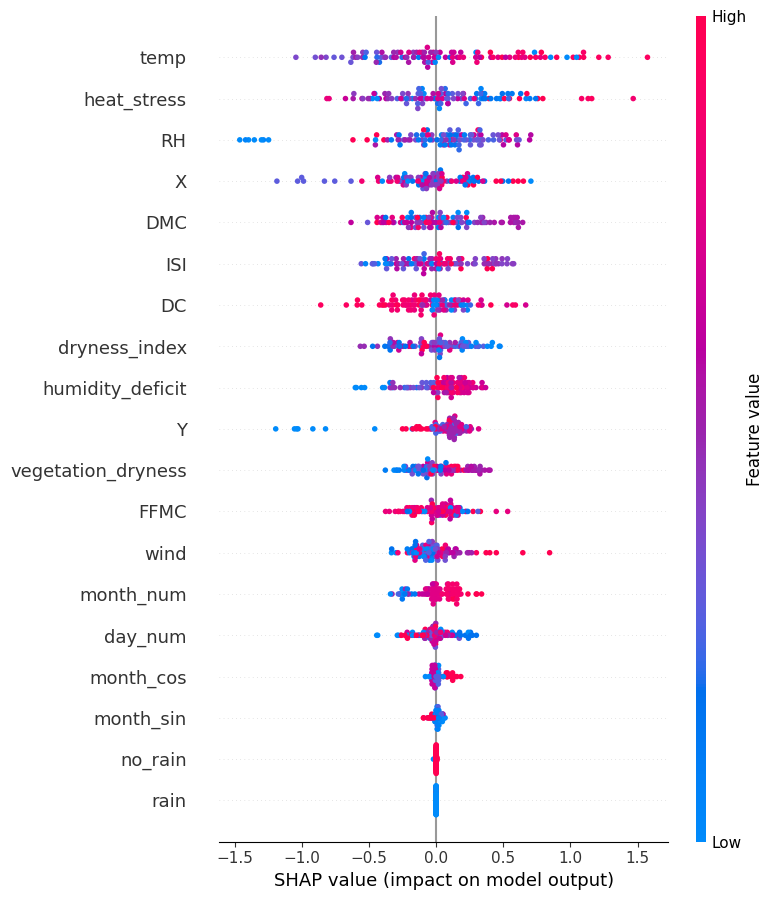

In [9]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig("../reports/shap_summary.png")

plt.show()

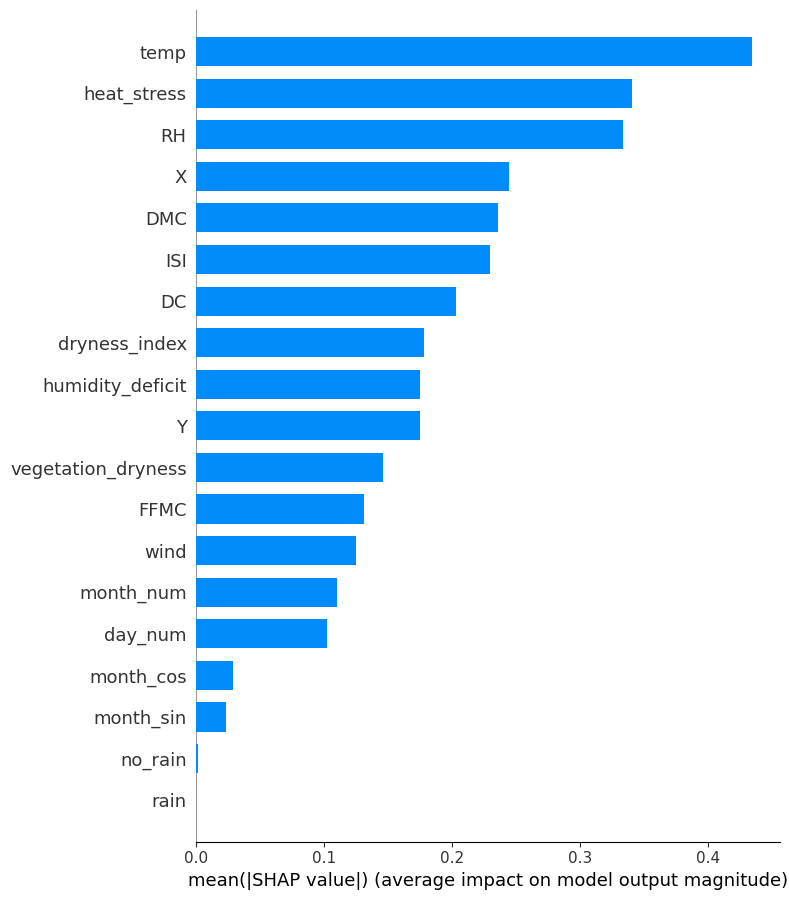

In [10]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig("../reports/shap_bar.png")

plt.show()

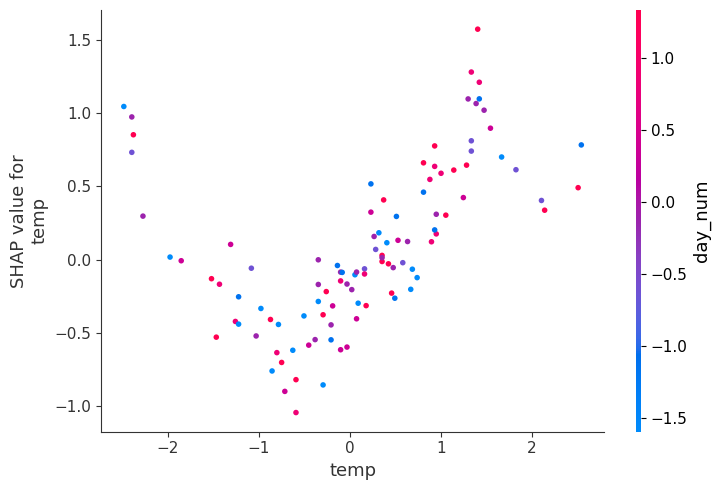

In [11]:
shap.dependence_plot(
    "temp",
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig("../reports/shap_temp_dependence.png")

plt.show()

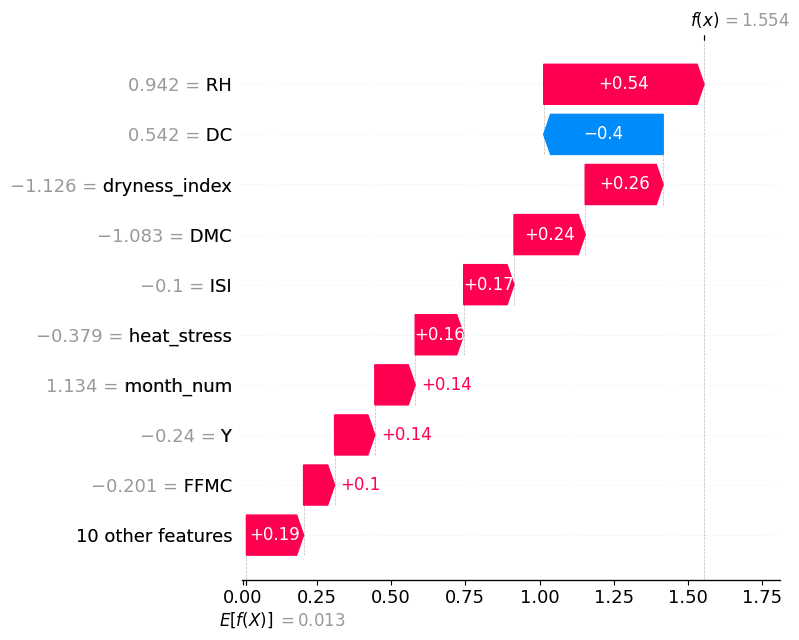

In [12]:
sample_index = 5

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_index],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample_index],
        feature_names=X_test.columns
    ),
    show=False
)

plt.tight_layout()

plt.savefig("../reports/shap_waterfall.png")

plt.show()

In [13]:
results = X_test.copy()

results["actual"] = y_test.values

results["predicted"] = y_preds

results["probability"] = y_probs

In [15]:
false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print(false_negatives.head())

           X         Y      FFMC       DMC        DC       ISI      temp  \
0   1.422082 -1.033240 -0.629488 -0.224638 -1.273700 -0.963894 -0.784650   
1  -1.177379  0.552407 -0.129314  2.816538  1.232757 -0.380951 -0.452222   
21 -1.610623 -1.826063  0.037410  0.826749  0.788934  0.201992  1.384876   
24  0.988838 -0.240416 -0.391310 -0.103807 -0.462894 -0.596856  0.667532   
26 -0.744136 -0.240416  0.585220  0.481518  0.666873  1.022431 -0.032314   

          RH      wind     rain  ...   no_rain  heat_stress  \
0   2.111716 -0.051917 -0.07355  ...  0.118678    -0.486724   
1   0.819212 -0.277757 -0.07355  ...  0.118678    -0.455025   
21 -0.596387 -1.294041 -0.07355  ...  0.118678    -0.745410   
24  0.757665  0.456225 -0.07355  ...  0.118678     1.028599   
26  0.265282 -0.277757 -0.07355  ...  0.118678    -0.210490   

    vegetation_dryness  month_num   day_num  month_sin  month_cos  actual  \
0            -0.281048  -0.629786 -1.593706   0.736308  -2.016111       1   
1         

In [16]:
false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

print(false_positives.head())

           X         Y      FFMC       DMC        DC       ISI      temp  \
2   0.555595  0.552407  0.323224 -0.128914  0.817348 -0.165046  0.160144   
5   0.988838 -0.240416 -0.200767 -1.083009  0.541610 -0.100274 -1.309535   
8   0.988838 -0.240416 -0.057861 -1.178732  0.487583 -0.532084 -0.137291   
11 -1.610623 -1.826063  0.632855  0.608626  0.725702 -0.229817  1.139929   
12 -0.310892  0.552407  0.132682 -1.252486 -1.892811 -0.359360 -0.102299   

          RH      wind     rain  ...   no_rain  heat_stress  \
2  -0.596387 -1.294041 -0.07355  ...  0.118678    -1.102024   
5   0.942308  0.738526 -0.07355  ...  0.118678    -0.378608   
8  -0.719482 -1.802183 -0.07355  ...  0.118678    -1.647132   
11 -0.534839 -0.277757 -0.07355  ...  0.118678     0.472170   
12 -0.965673 -0.560058 -0.07355  ...  0.118678    -0.508800   

    vegetation_dryness  month_num   day_num  month_sin  month_cos  actual  \
2            -0.120910   0.693071  0.847716  -0.651214   0.577620       0   
5         

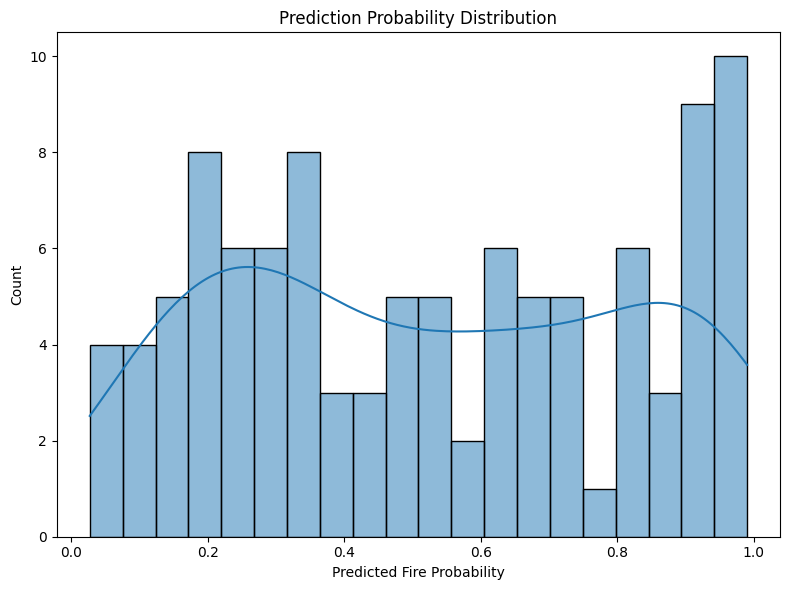

In [17]:
plt.figure(figsize=(8,6))

sns.histplot(
    y_probs,
    bins=20,
    kde=True
)

plt.title("Prediction Probability Distribution")

plt.xlabel("Predicted Fire Probability")

plt.tight_layout()

plt.savefig("../reports/probability_distribution.png")

plt.show()

In [18]:
false_negatives.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,...,no_rain,heat_stress,vegetation_dryness,month_num,day_num,month_sin,month_cos,actual,predicted,probability
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,2.000000e+01,...,2.000000e+01,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0,20.0,20.000000
mean,-0.007622,-0.121493,0.012402,0.214199,0.240799,-0.257885,0.118153,0.056020,-0.314456,-7.355036e-02,...,1.186782e-01,-0.219972,0.200399,0.141881,-0.153267,-0.172385,0.011405,1.0,0.0,0.309440
std,1.080597,0.739944,0.466634,1.052141,0.997985,0.571235,0.825369,1.074125,0.972461,1.423831e-17,...,1.423831e-17,0.862220,1.033000,0.903401,1.136604,0.867210,1.038668,0.0,0.0,0.133528
min,-1.610623,-1.826063,-1.391657,-1.593010,-1.962445,-1.222980,-1.519489,-1.827342,-1.802183,-7.355036e-02,...,1.186782e-01,-1.591093,-1.586178,-2.393596,-1.593706,-0.651214,-2.016111,1.0,0.0,0.059224
25%,-0.852447,-0.240416,-0.159086,-0.224638,0.115196,-0.640037,-0.526581,-0.611774,-1.124660,-7.355036e-02,...,1.186782e-01,-0.769609,-0.248647,0.141881,-1.593706,-0.651214,-0.719246,1.0,0.0,0.229422
50%,-0.094271,-0.240416,0.037410,-0.033191,0.667673,-0.413336,0.081411,0.111413,-0.277757,-7.355036e-02,...,1.186782e-01,-0.332758,-0.036822,0.693071,-0.128853,-0.651214,0.577620,1.0,0.0,0.322313
75%,0.663905,0.552407,0.370859,0.544679,0.849664,0.018473,0.698151,0.773052,0.456225,-7.355036e-02,...,1.186782e-01,0.520142,0.573861,0.693071,0.847716,-0.338354,0.577620,1.0,0.0,0.388448
max,1.855325,1.345230,0.585220,2.816538,1.232757,1.022431,1.384876,2.111716,1.980650,-7.355036e-02,...,1.186782e-01,1.256719,2.711711,0.693071,1.336000,2.123831,1.874486,1.0,0.0,0.497607


In [19]:
summary = {
    "ROC_AUC": float(roc_auc_score(y_test, y_probs)),
    "Balanced_Accuracy": float(
        balanced_accuracy_score(y_test, y_preds)
    ),
    "MCC": float(
        matthews_corrcoef(y_test, y_preds)
    ),
    "False_Negatives": int(len(false_negatives)),
    "False_Positives": int(len(false_positives))
}

summary

{'ROC_AUC': 0.6811111111111111,
 'Balanced_Accuracy': 0.6248148148148148,
 'MCC': 0.24949106196442594,
 'False_Negatives': 20,
 'False_Positives': 19}

In [20]:
with open("../reports/evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

In [21]:
html_content = f"""
<html>
<head>
<title>Forest Fire Model Evaluation</title>
</head>

<body>

<h1>Forest Fire Prediction Evaluation</h1>

<h2>Metrics</h2>

<ul>
<li>ROC AUC: {summary['ROC_AUC']:.3f}</li>
<li>Balanced Accuracy: {summary['Balanced_Accuracy']:.3f}</li>
<li>MCC: {summary['MCC']:.3f}</li>
<li>False Negatives: {summary['False_Negatives']}</li>
<li>False Positives: {summary['False_Positives']}</li>
</ul>

</body>
</html>
"""

with open("../reports/evaluation_report.html", "w") as f:
    f.write(html_content)